Task 1: Search algorithms

In [10]:
import pandas as pd

df = pd.read_csv('postings.csv')

if len(df) > 100000:
    df = df.sample(n=100000, random_state=42)
keys_sort = sorted(df.iloc[:, 0].dropna().tolist())
df.head(5) 

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
73989,3902944011,Current Power,Senior Automation Engineer - Power Systems,The Senior Automation / Power Systems Engineer...,NaN,NaN,"Houston, TX",760913.0,22.0,NaN,...,NaN,1.713280e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,77002.0,48201.0
59308,3901960222,DISH Network,DISH Installation Technician - Field,"Company Summary\n\nDISH, an EchoStar Company, ...",19.75,HOURLY,"Orange, TX",4296.0,5.0,NaN,...,NaN,1.713478e+12,jobs.dish.com,0,FULL_TIME,USD,BASE_SALARY,41080.0,77630.0,48361.0
44663,3900944095,"Coca-Cola Bottling Company UNITED, Inc.",Order Builder,Division: North Alabama\n\nDepartment : Oxford...,NaN,NaN,"Oxford, AL",136791.0,4.0,NaN,...,NaN,1.713389e+12,careers.cokeonena.com,0,FULL_TIME,NaN,NaN,NaN,36203.0,1015.0
81954,3903878594,Denver7 (KMGH-TV),"Mountain Multimedia Journalist, KMGH","KMGH, the E.W. Scripps Company ABC affiliate i...",NaN,NaN,"Denver, CO",11500365.0,4.0,NaN,...,NaN,1.713496e+12,scripps.wd5.myworkdayjobs.com,0,FULL_TIME,NaN,NaN,NaN,80202.0,8031.0
113151,3905670593,BAYADA Home Health Care,Licensed Practical Nurse (LPN),"Come for the Flexibility, Stay for the Culture...",35.00,HOURLY,"Teterboro, NJ",19472.0,4.0,NaN,...,NaN,1.713521e+12,jsv3.recruitics.com,0,FULL_TIME,USD,BASE_SALARY,67600.0,7608.0,34003.0


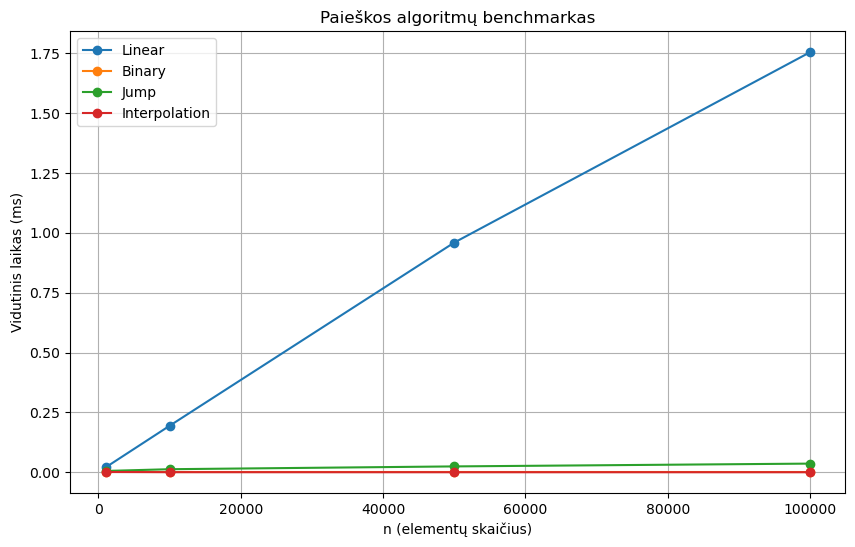


--- Paieškos algoritmų benchmark (laikas ms) ---
          Linear    Binary      Jump  Interpolation
n                                                  
1000    0.020208  0.001792  0.005667       0.001320
10000   0.194236  0.001319  0.012972       0.000584
50000   0.959389  0.001319  0.024667       0.000402
100000  1.754402  0.001264  0.036361       0.000389


In [12]:
import time
import matplotlib.pyplot as plt
import numpy as np


def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1

def jump_search(arr, target):
    n = len(arr)
    jump = int(n**0.5)
    prev = 0
    while prev < n and arr[min(jump, n)-1] < target:
        prev = jump
        jump += int(n**0.5)
        if prev >= n:
            return -1
    for i in range(prev, min(jump, n)):
        if arr[i] == target:
            return i
    return -1

def interpolation_search(arr, target):
    low = 0
    high = len(arr) - 1
    while low <= high and arr[low] <= target <= arr[high]:
        if low == high:
            if arr[low] == target: return low
            return -1
        pos = low + int(((float(high - low) / (arr[high] - arr[low])) * (target - arr[low])))
        if arr[pos] == target:
            return pos
        if arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    return -1


def benchmark_search(func, arr, target):
    times = []
    for _ in range(3): 
        start = time.perf_counter()
        func(arr, target)
        end = time.perf_counter()
        times.append((end - start) * 1000) 
    return sum(times) / len(times)


sizes = [1000, 10000, 50000, 100000]
results = {name: [] for name in ["Linear", "Binary", "Jump", "Interpolation"]}
actual_sizes = []

for n in sizes:
    if n > len(keys_sort): continue
    actual_sizes.append(n)
    subset = keys_sort[:n] 
    target = subset[-1] 

    results["Linear"].append(benchmark_search(linear_search, subset, target))
    results["Binary"].append(benchmark_search(binary_search, subset, target))
    results["Jump"].append(benchmark_search(jump_search, subset, target))
    results["Interpolation"].append(benchmark_search(interpolation_search, subset, target))


plt.figure(figsize=(10, 6))
for name, times in results.items():
    plt.plot(actual_sizes, times, label=name, marker='o')
plt.xlabel('n (elementų skaičius)')
plt.ylabel('Vidutinis laikas (ms)')
plt.title('Paieškos algoritmų benchmarkas')
plt.legend()
plt.grid(True)
plt.show()

benchmark_df = pd.DataFrame(results, index=actual_sizes)
benchmark_df.index.name = 'n'

print("\n--- Paieškos algoritmų benchmark (laikas ms) ---")
print(benchmark_df)

In [15]:
bad_input = [2**i for i in range(20)]
target_val = 2

t_bin_bad = benchmark_search(binary_search, bad_input, target_val)
t_int_bad = benchmark_search(interpolation_search, bad_input, target_val)

print("\n--- Specifinis testas (Netolygūs duomenys) ---")
print(f"Duomenys: {bad_input[:5]} ... {bad_input[-1:]}")
print(f"Binary Search:        {t_bin_bad:.10f} ms")
print(f"Interpolation Search: {t_int_bad:.10f} ms")


--- Specifinis testas (Netolygūs duomenys) ---
Duomenys: [1, 2, 4, 8, 16] ... [524288]
Binary Search:        0.0013056657 ms
Interpolation Search: 0.0099720006 ms


Taigi Interpolation Search veikia ženklai lėčiau, nei Binary Search, nes duomenys pasiskirstę netolygiai, todėl Interpolation Search ilgiau užtrunka(reikia atlikti daugiau žingsnių, ir atlieka klaidingas spėjimus)

Task 2: Binary Search Tree (BST) and traversals


In [28]:
from collections import deque

class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None

class BinarySearchTree:
    def __init__(self):
        self.root = None

    def insert(self, key, value):
        def _insert(node, key, value):
            if node is None:
                return Node(key, value)
            if key < node.key:
                node.left = _insert(node.left, key, value)
            elif key > node.key:
                node.right = _insert(node.right, key, value)
            else:
                node.value = value
            return node
        self.root = _insert(self.root, key, value)

    def search(self, key):
        def _search(node, key):
            if node is None or node.key == key:
                return node.value if node else None
            if key < node.key:
                return _search(node.left, key)
            return _search(node.right, key)
        return _search(self.root, key)

    def delete(self, key):
        def _min_value_node(node):
            current = node
            while current.left is not None:
                current = current.left
            return current

        def _delete(node, key):
            if node is None:
                return node
            if key < node.key:
                node.left = _delete(node.left, key)
            elif key > node.key:
                node.right = _delete(node.right, key)
            else:
                # 1 ir 2 atvejai: lapas arba vienas vaikas
                if node.left is None:
                    return node.right
                elif node.right is None:
                    return node.left
                # 3 atvejis: du vaikai
                temp = _min_value_node(node.right)
                node.key, node.value = temp.key, temp.value
                node.right = _delete(node.right, temp.key)
            return node
        self.root = _delete(self.root, key)

    def inorder(self):
        res = []
        def _traverse(node):
            if node:
                _traverse(node.left); res.append(node.key); _traverse(node.right)
        _traverse(self.root)
        return res

    def preorder(self):
        res = []
        def _traverse(node):
            if node:
                res.append(node.key); _traverse(node.left); _traverse(node.right)
        _traverse(self.root)
        return res

    def postorder(self):
        res = []
        def _traverse(node):
            if node:
                _traverse(node.left); _traverse(node.right); res.append(node.key)
        _traverse(self.root)
        return res

    def bfs(self):
        if not self.root: return []
        res, queue = [], deque([self.root])
        while queue:
            node = queue.popleft()
            res.append(node.key)
            if node.left: queue.append(node.left)
            if node.right: queue.append(node.right)
        return res

In [29]:

import pandas as pd

df = pd.read_csv("postings.csv")

df_subset = df.iloc[:50000].copy()

BST_KEY = "max_salary"
df_clean = df_subset.dropna(subset=[BST_KEY]).copy()

bst = BinarySearchTree()
for _, row in df_clean.iterrows():
    bst.insert(row[BST_KEY], row.to_dict())

print(f"Clean: {len(df_clean)} elementų.")

Clean: 11925 elementų.


In [30]:
def range_query(self, low, high):
    res = []
    def _traverse(node):
        if not node:
            return
        if node.key > low:
            _traverse(node.left)
        if low <= node.key <= high:
            res.append(node.value)
        if node.key < high:
            _traverse(node.right)
    _traverse(self.root)
    return res


BinarySearchTree.range_query = range_query

In [32]:
import time

low_val = 50000.0
high_val = 80000.0

start_bst = time.perf_counter()
bst_res = bst.range_query(low_val, high_val)
t_bst = (time.perf_counter() - start_bst) * 1000

data_list = df_clean.to_dict('records')
start_lazy = time.perf_counter()
lazy_res = [row for row in data_list if low_val <= row[BST_KEY] <= high_val]
t_lazy = (time.perf_counter() - start_lazy) * 1000

print(f"BST laikas su range_query: {t_bst:.4f} ms")
print(f"Baseline laikas(lazy baseline): {t_lazy:.4f} ms")
print(f"Rasta elementų: {len(bst_res)}")

BST laikas su range_query: 0.4622 ms
Baseline laikas(lazy baseline): 3.2812 ms
Rasta elementų: 219


Task 3: Heap and top-k

In [34]:
class MinHeap:
    def __init__(self):
        self.heap = []

    def insert(self, value):
        self.heap.append(value)
        self._bubble_up(len(self.heap) - 1)

    def extract(self):
        if not self.heap: return None
        if len(self.heap) == 1: return self.heap.pop()
        root = self.heap[0]
        self.heap[0] = self.heap.pop()
        self._bubble_down(0)
        return root

    def peek(self):
        return self.heap[0] if self.heap else None

    def size(self):
        return len(self.heap)

    def _bubble_up(self, index):
        parent = (index - 1) // 2
        if index > 0 and self.heap[index][0] < self.heap[parent][0]:
            self.heap[index], self.heap[parent] = self.heap[parent], self.heap[index]
            self._bubble_up(parent)

    def _bubble_down(self, index):
        left, right = 2 * index + 1, 2 * index + 2
        smallest = index
        if left < len(self.heap) and self.heap[left][0] < self.heap[smallest][0]:
            smallest = left
        if right < len(self.heap) and self.heap[right][0] < self.heap[smallest][0]:
            smallest = right
        if smallest != index:
            self.heap[index], self.heap[smallest] = self.heap[smallest], self.heap[index]
            self._bubble_down(smallest)

In [35]:
import pandas as pd
import time

df = pd.read_csv("postings.csv")
n = 50000
data_subset = df.iloc[:n].copy()

TOPK_KEY = "min_salary" 
data_clean = data_subset.dropna(subset=[TOPK_KEY])
k = 10

start_heap = time.perf_counter()
heap = MinHeap()

for _, row in data_clean.iterrows():
    val = (row[TOPK_KEY], row.to_dict())
    if heap.size() < k:
        heap.insert(val)
    elif val[0] > heap.peek()[0]:
        heap.extract()
        heap.insert(val)

heap_results = []
while heap.size() > 0:
    heap_results.append(heap.extract())
heap_results.reverse()
t_heap = (time.perf_counter() - start_heap) * 1000

start_naive = time.perf_counter()
naive_results = data_clean.sort_values(by=TOPK_KEY, ascending=False).head(k)
t_naive = (time.perf_counter() - start_naive) * 1000


print(f"--- Top did. atlygis mažiausiame atlygio kategorijoje-{k} rezultatai pagal {TOPK_KEY} ---")
for i, res in enumerate(heap_results):
    print(f"{i+1}. {res[0]}")

print(f"\nHeap laikas:    {t_heap:.4f} ms")
print(f"Naive laikas:   {t_naive:.4f} ms")

--- Top did. atlygis mažiausiame atlygio kategorijoje-10 rezultatai pagal min_salary ---
1. 560000.0
2. 550000.0
3. 540000.0
4. 450000.0
5. 445000.0
6. 435000.0
7. 420000.0
8. 400000.0
9. 400000.0
10. 400000.0

Heap laikas:    181.8227 ms
Naive laikas:   4.0453 ms
